In [1]:
%matplotlib inline
import matplotlib.pyplot as plt 
from matplotlib import gridspec
from sklearn.datasets import make_classification
import numpy as np
# pick the seed for reproducibility - change it to explore the effects of random variations
np.random.seed(0)
import random

In [2]:
n = 100
X, Y = make_classification(n_samples = n, n_features=2,
                           n_redundant=0, n_informative=2, flip_y=0.2)
X = X.astype(np.float32)
Y = Y.astype(np.int32)

# Split into train and test dataset
train_x, test_x = np.split(X, [n*8//10])
train_labels, test_labels = np.split(Y, [n*8//10])

In [3]:
def plot_dataset(suptitle, features, labels):
    # prepare the plot
    fig, ax = plt.subplots(1, 1)
    #pylab.subplots_adjust(bottom=0.2, wspace=0.4)
    fig.suptitle(suptitle, fontsize = 16)
    ax.set_xlabel('$x_i[0]$ -- (feature 1)')
    ax.set_ylabel('$x_i[1]$ -- (feature 2)')

    colors = ['r' if l else 'b' for l in labels]
    ax.scatter(features[:, 0], features[:, 1], marker='o', c=colors, s=100, alpha = 0.5)
    fig.show()

C:\Users\jsand\AppData\Local\Temp\ipykernel_26460\1441799467.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


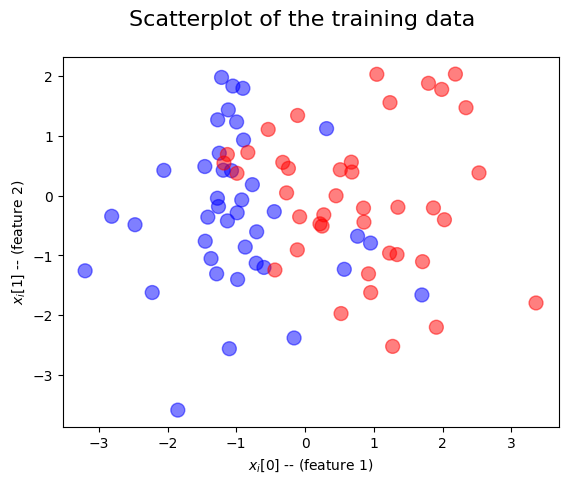

In [4]:
plot_dataset('Scatterplot of the training data', train_x, train_labels)
plt.show()

Loss functions for regression

In [10]:
def plot_loss_functions(suptitle, functions, ylabels, xlabel):
    fig, ax = plt.subplots(1,len(functions), figsize=(9, 3))
    plt.subplots_adjust(bottom=0.2, wspace=0.4)
    fig.suptitle(suptitle)
    for i, fun in enumerate(functions):
        ax[i].set_xlabel(xlabel)
        if len(ylabels) > i:
            ax[i].set_ylabel(ylabels[i])
        ax[i].plot(x, fun)
    plt.show()

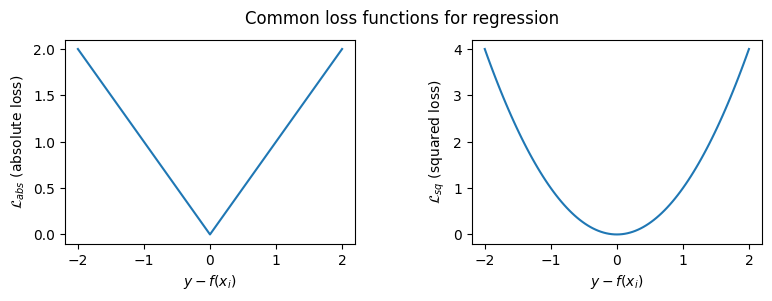

In [13]:
x = np.linspace(-2, 2, 101)
plot_loss_functions(
    'Common loss functions for regression',
    [np.abs(x), np.power(x, 2)],
    ['$\mathcal{L}_{abs}$ (absolute loss)', '$\mathcal{L}_{sq}$ (squared loss)'],
    '$y - f(x_i)$'
)

Loss functions for classification

In [14]:
x = np.linspace(0,1,100)
def zero_one(d):
    if d < 0.5:
        return 0
    return 1
zero_one_v = np.vectorize(zero_one)

def logistic_loss(fx):
    # assumes y == 1
    return -np.log(fx)

C:\Users\jsand\AppData\Local\Temp\ipykernel_26460\331859503.py:10: RuntimeWarning: divide by zero encountered in log
  return -np.log(fx)


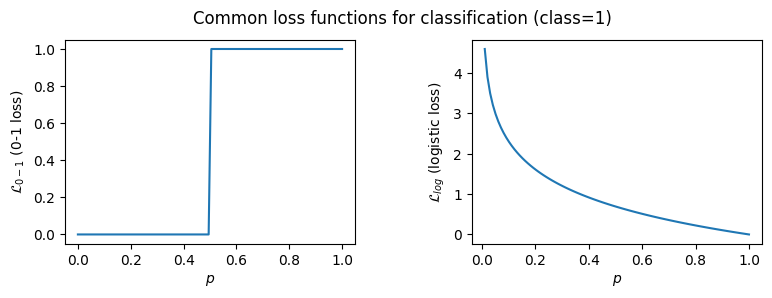

In [19]:
plot_loss_functions(
    'Common loss functions for classification (class=1)',
    [zero_one_v(x), logistic_loss(x)],
    ['$\mathcal{L}_{0-1}$ (0-1 loss)', '$\mathcal{L}_{log}$ (logistic loss)'],
    '$p$'
)